In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize

In [2]:
import time

In [3]:
def allj_One_n(n, N, end=[]):
    # given n, N, find all possible sets of j
    combos=[]
    if N==1:
        for row in end:
            combos.append([n-sum(row)]+row)
        return combos
    if len(end)==0:
        for value in range(n+1):
            combos.append([value])
        return allj_One_n(n, N-1, combos)
    for row in end:
        for j in range(n-sum(row)+1):
            combos.append([j]+row)
    return allj_One_n(n, N-1, combos)       

In [4]:
def bubbleSort(combos):
    for i in range(len(combos)):
        for r in range(0,len(combos)-i-1):
            if combos[r][0]>combos[r+1][0]:
                temp=combos[r]
                combos[r]=combos[r+1]
                combos[r+1] = temp
    return combos

In [5]:
def getImportantOmegas_One_n(n, normal_omegas, N):
    all_combos = []
    j_combos_list = allj_One_n(n, N-1)
    for jcombo in j_combos_list:
        omega=0
        for j_index in range(len(jcombo)):
            if jcombo[j_index]!=0:
                omega+=jcombo[j_index]*normal_omegas[j_index]
        all_combos.append([omega, n, jcombo])
    return bubbleSort(all_combos)

In [6]:
def getImportantOmegas(n_max, normal_omegas, N):
    all_combos=[]
    for n in range(1,n_max+1):
        j_combos_list = allj_One_n(n, N-1)
        for jcombo in j_combos_list:
            omega=0
            for j_index in range(len(jcombo)):
                if jcombo[j_index]!=0:
                    omega+=jcombo[j_index]*normal_omegas[j_index]
            all_combos.append([omega, n, jcombo])
    return bubbleSort(all_combos)

In [7]:
def getOnlyOmegas(n_max, normal_omegas, N):
    omegas = []
    combos = getImportantOmegas(n_max, normal_omegas, N)
    for row in range(len(combos)):
        omegas.append(combos[row][0])
    return omegas

In [8]:
def addDeltaEqualsZeroRegions(combos, step=None, deviation=1.2):
    if deviation<0.5:
        print("Error: deviation has to be above 0.5")
        return
    new_combos=[]
    if step==None:
        omega_range = combos[len(combos)-1][0]-combos[0][0]
        averageStep = omega_range/(len(combos)-1)*deviation
    else:
        averageStep = step
    for i in range(0,len(combos)-1):
        new_combos.append(combos[i])
        diff = combos[i+1][0]-combos[i][0] 
        if diff>averageStep:
            if diff>2*averageStep:
                new_combos.append([combos[i][0]+averageStep, -1, [-1]])
                new_combos.append([combos[i+1][0]-averageStep, -1, [-1]])
            else:
                new_combos.append([combos[i][0]+diff/2, -1, [-1]])
        #new_combos.append([omega_new,-1,[-1]])
    new_combos.append(combos[len(combos)-1])
    return new_combos

# Structure Factor Code

In [9]:

def debye_waller(q, m, B, omegas, ell, N):
    # result=0
    # for nu in range(N-1):
    #     result+= B[nu, ell]*np.conjugate(B[nu, ell])/omegas[nu]
    result = np.sum(B[:, ell]*np.conjugate(B[:, ell])/omegas)* q**2/(4*m)
    return result

In [10]:
def combos_helper_function_diag(j_vector, B, omegas, N, ell):
    '''
    For each set of j, calculate the product in the structure factor in the diagonal term
    '''
    # tot=1
    # for r in range(N):
    #     if j_vector[r]!=0:
    #         tot*=1/factorial(j_vector[r])*(B[ell][r]*np.conjugate(B[ell][r])/omegas[r])**j_vector[r]
    ind = np.nonzero(np.array(j_vector))
    tot = np.prod(1/factorial(j_vector[ind])*(B[ind, ell]*np.conjugate(B[ind, ell])/omegas[ind])**j_vector[ind])
    return tot

In [11]:
def combos_helper_function_offdiag(j_vector, B, omegas, N, ell, ell_prime):
    # tot=1
    # for r in range(N):
    #     if j_vector[r]!=0:
    #         tot*=1/factorial(j_vector[r])*(B[ell][r]*np.conjugate(B[ell_prime][r])/omegas[r])**j_vector[r]
    ind = np.nonzero(np.array(j_vector))
    tot = np.prod(1/factorial(j_vector[ind])*(B[ind, ell]*np.conjugate(B[ind, ell_prime])/omegas[ind])**j_vector[ind])
    return tot

In [12]:
def diagonal_C_singleCombo(q, m, omegas, n, j_vector,N,ell,B, V=1):
    '''
    For each set of j, calculate one term in the summation of C_ll
    '''
    j_vector = np.array(j_vector)
    expDebyeWaller = np.exp(-2*debye_waller(q, m, B, omegas, ell, N))
    c=expDebyeWaller/V * (q**2/(2*m))**n * 2*np.pi * combos_helper_function_diag(j_vector, B, omegas, N, ell)
    return c

In [13]:
def offDiagonal_C_singleCombo(q, m, omegas, n, j_vector, N ,ell, ell_prime, B , V=1, a=0.001):
    j_vector = np.array(j_vector)
    expDebyeWaller = np.exp(-debye_waller(q, m, B, omegas, ell, N)-debye_waller(q, m, B, omegas, ell_prime, N))
    c=expDebyeWaller/V * (q**2/(2*m))**n * 2*np.pi*combos_helper_function_offdiag(j_vector, B, omegas, N, ell, ell_prime)
    c = c*np.cos(q*a*(ell-ell_prime))
    return c

In [14]:
def StructureFactorIntegral_singleCombo(q, m, omegas, n, j, N ,B , V=1, a=0.001, A=1):
    # For each set of j, sum all C_ll terms over N
    tot=np.zeros(len(q),dtype=np.complex128)
    if n==-1: #n=-1 is when the delta function equals 0
        return tot
    for ell in range(N):
        for ell_prime in range(N):
            if ell==ell_prime:
                tot+=diagonal_C_singleCombo(q, m, omegas, n, j,N,ell,B, V)
            else:
                tot+=offDiagonal_C_singleCombo(q, m, omegas, n, j, N ,ell, ell_prime, B , V, a)
    return A**2 * tot

In [15]:
def StructureFactorIntegral_singleCombo_diag(q, m, omegas, n, j, N ,B , V=1, a=0.001, A=1):
    # For each set of j, sum all C_ll terms over N
    tot=np.zeros(len(q),dtype=np.complex128)
    if n==-1: #n=-1 is when the delta function equals 0
        return tot
    for ell in range(N):
        tot+=diagonal_C_singleCombo(q, m, omegas, n, j, N,ell,B, V)
    return A**2 * tot

# Graphing

In [16]:
def makeGraph(N, q, params, combos, definition=100, colmap = 'CMRmap', contour=False, log=False, minlog=1e-6):
    #omegas = np.array([com[0] for com in combos])
    omegas=[combos[0][0]]
    z=[StructureFactorIntegral_singleCombo(
            q, params['m'], params['ome'], combos[0][1], combos[0][2], N ,
            params['B'] , params['V'], params['a'], params['A'])]
    for c in range(1,len(combos)):            
        z_point = StructureFactorIntegral_singleCombo(
            q, params['m'], params['ome'], combos[c][1], combos[c][2], N ,
            params['B'] , params['V'], params['a'], params['A'])
        if combos[c][0]==combos[c-1][0]:
            z[len(z)-1]+=z_point
        else:
            z.append(z_point)
            omegas.append(combos[c][0])
    X, Y = np.meshgrid(q, omegas)
    if log==True:
        z = [np.log10(z_val+minlog) for z_val in z]
    Z = np.array(z).reshape(len(omegas), len(q))
    Z=np.real(Z)
    if contour:  
        graph= plt.contourf(X, Y, Z, definition, cmap=colmap)
    else:
        graph=plt.pcolormesh(X, Y, Z, cmap=colmap)
    #plt.xscale('log')
    return graph

In [17]:
m=26161e3 # keV
omegaNaught = 10e-6 # keV, correpsonds to maximum energy of 20 meV
N=20

mat = np.arange(1, N+1) * np.arange(1, N).reshape(N-1,-1)
B = np.exp(1j*2*np.pi*mat/N)/np.sqrt(N)
omegas = np.sqrt(2*(1-np.cos(2*np.pi*np.arange(1, N)/N)))*omegaNaught

SFI_params = {'m':m, 'B':B,'V':5*N, "A":10, "a":2*np.pi/2.28, 'N':N, 'ome':omegas, 'n_max':3}

In [18]:
q=np.linspace(0.01, 1.5, 1000)
#log10q=np.linspace(-1.5, 3, 1000)
#q=10**log10q
omega_dispersion_list=np.sqrt(2*(1-np.cos(q*SFI_params['a'])))*omegaNaught

In [19]:
SFI_params['n_max']=3
print("maximum n is 3")
combos=getImportantOmegas(SFI_params['n_max'], SFI_params['ome'], N)
combos = addDeltaEqualsZeroRegions(combos, step=1e-7)

maximum n is 3


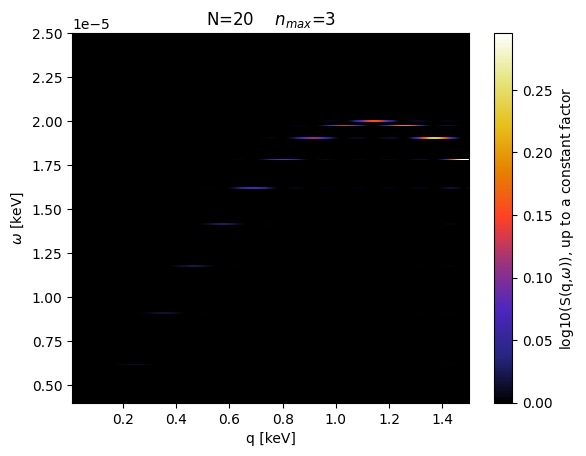

61.83380722999573


In [20]:
start=time.time()
plt.title('N='+str(N)+"\t"+r"$n_{max}$="+str(SFI_params['n_max']))
#plt.plot(q, omega_dispersion_list, color="white", linewidth=1.5, alpha=0.2, linestyle="--", label="Dispersion Relation")
plt.ylim(0.4e-5, 2.5e-5)

graph= makeGraph(N, q, SFI_params, combos, 100, contour=False, log=False, minlog=1e-7)
plt.colorbar(graph,label=r'log10(S(q,$\omega$)), up to a constant factor')

plt.xlabel("q [keV]")
plt.ylabel(r"$\omega$ [keV]")
#plt.legend(labelcolor="white",framealpha=0.2)
#plt.xscale('log')

plt.savefig('Nparticle_structure_factor_2d', dpi=300,bbox_inches="tight")

plt.show()
print(time.time()-start)

In [21]:
def makeDiagonalsGraph(N, q, params, combos, definition=100, colmap = 'CMRmap', contour=False):
    omegas = np.array([com[0] for com in combos])
    X, Y = np.meshgrid(q, omegas)
    z=[]
    for c in range(len(combos)):
        z_point = StructureFactorIntegral_singleCombo_diag(
            q, params['m'], params['ome'], combos[c][1], combos[c][2], N ,
            params['B'] , params['V'], params['a'], params['A'])
        z.append(z_point)
    Z = np.array(z).reshape(len(combos), len(q))
    Z=np.real(Z)
    if contour:  
        graph= plt.contourf(X, Y, Z, definition, cmap=colmap)
    else:
        graph=plt.pcolormesh(X, Y, Z, cmap=colmap)
    #plt.xscale('log')
    return graph

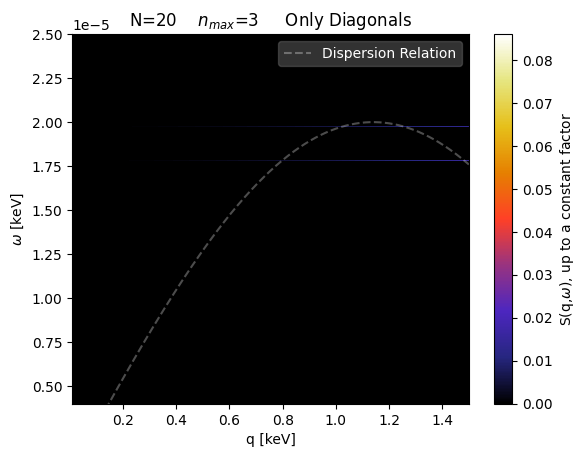

In [22]:
plt.title('N='+str(N)+"\t"+r"$n_{max}$="+str(SFI_params['n_max'])+"\tOnly Diagonals")
plt.plot(q, omega_dispersion_list, color="white", linewidth=1.5, alpha=0.3, linestyle="--", label="Dispersion Relation")
plt.ylim(0.4e-5, 2.5e-5)

graph= makeDiagonalsGraph(N, q, SFI_params, combos, 100)
plt.colorbar(graph,label=r'S(q,$\omega$), up to a constant factor')

plt.xlabel("q [keV]")
plt.ylabel(r"$\omega$ [keV]")
plt.legend(labelcolor="white",framealpha=0.2)

plt.savefig('Nparticle_structure_factor_2d_diagonals', dpi=300,bbox_inches="tight")

plt.show()

In [23]:
m=26161e3 # keV
omegaNaught = 10e-6 # keV, correpsonds to maximum energy of 20 meV
N=20

mat = np.arange(1, N+1) * np.arange(1, N).reshape(N-1,-1)
B = np.exp(1j*2*np.pi*mat/N)/np.sqrt(N)
omegas = np.sqrt(2*(1-np.cos(2*np.pi*np.arange(1, N)/N)))*omegaNaught
SFI_params = {'m':m, 'B':B,'V':5*N, "A":10, "a":2*np.pi/2.28, 'N':N, 'ome':omegas, 'n_max':5}

In [24]:
q=np.linspace(10, 15, 1000)
#omega_dispersion_list=np.sqrt(2*(1-np.cos(q*SFI_params['a'])))*omegaNaught

In [25]:
#q=np.linspace(0.01, 100, 1000)
#log10q=np.linspace(-1.5, 3, 1000)
#q=10**log10q
omega_dispersion_list=np.sqrt(2*(1-np.cos(q*SFI_params['a'])))*omegaNaught

In [26]:
print("n=3")
combos=getImportantOmegas_One_n(3, SFI_params['ome'], N)
combos = addDeltaEqualsZeroRegions(combos, step=1e-7)

n=3


C:\Users\xylin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


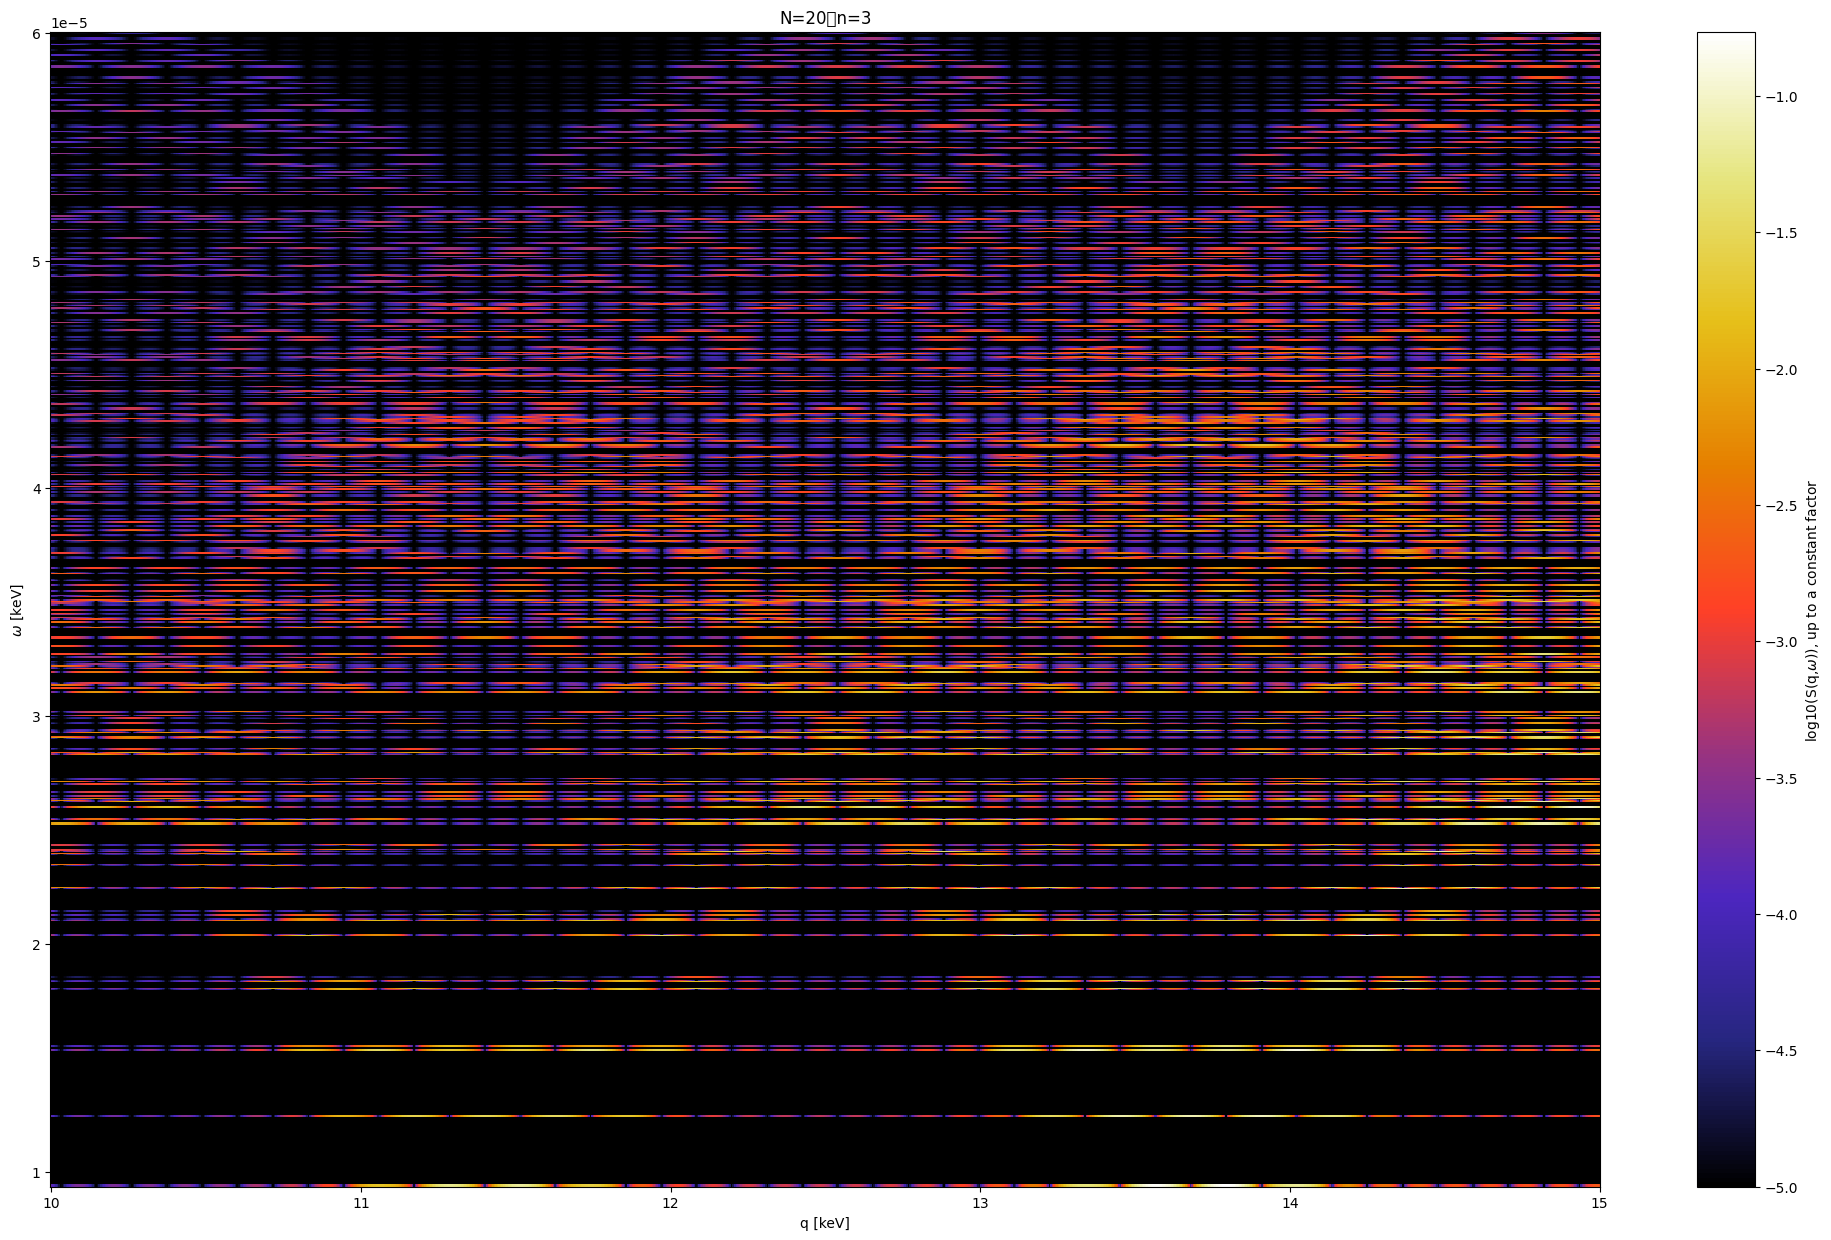

In [27]:
plt.figure(figsize=(25,15))
plt.title('N='+str(N)+"\t"+"n="+str(3))
#plt.plot(q, omega_dispersion_list, color="white", linewidth=1.5, alpha=0.2, linestyle="--", label="Dispersion Relation")
#plt.ylim(0.4e-5, 5e-5)

graph= makeGraph(N, q, SFI_params, combos, 100,log=True, minlog=1e-5)
plt.colorbar(graph,label=r'log10(S(q,$\omega$)), up to a constant factor')
#plt.xscale('log')

plt.xlabel("q [keV]")
plt.ylabel(r"$\omega$ [keV]")
#plt.legend(labelcolor="white",framealpha=0.2)

#plt.savefig('Nparticle_structure_factor_2d_one_n', dpi=300,bbox_inches="tight")

plt.show()

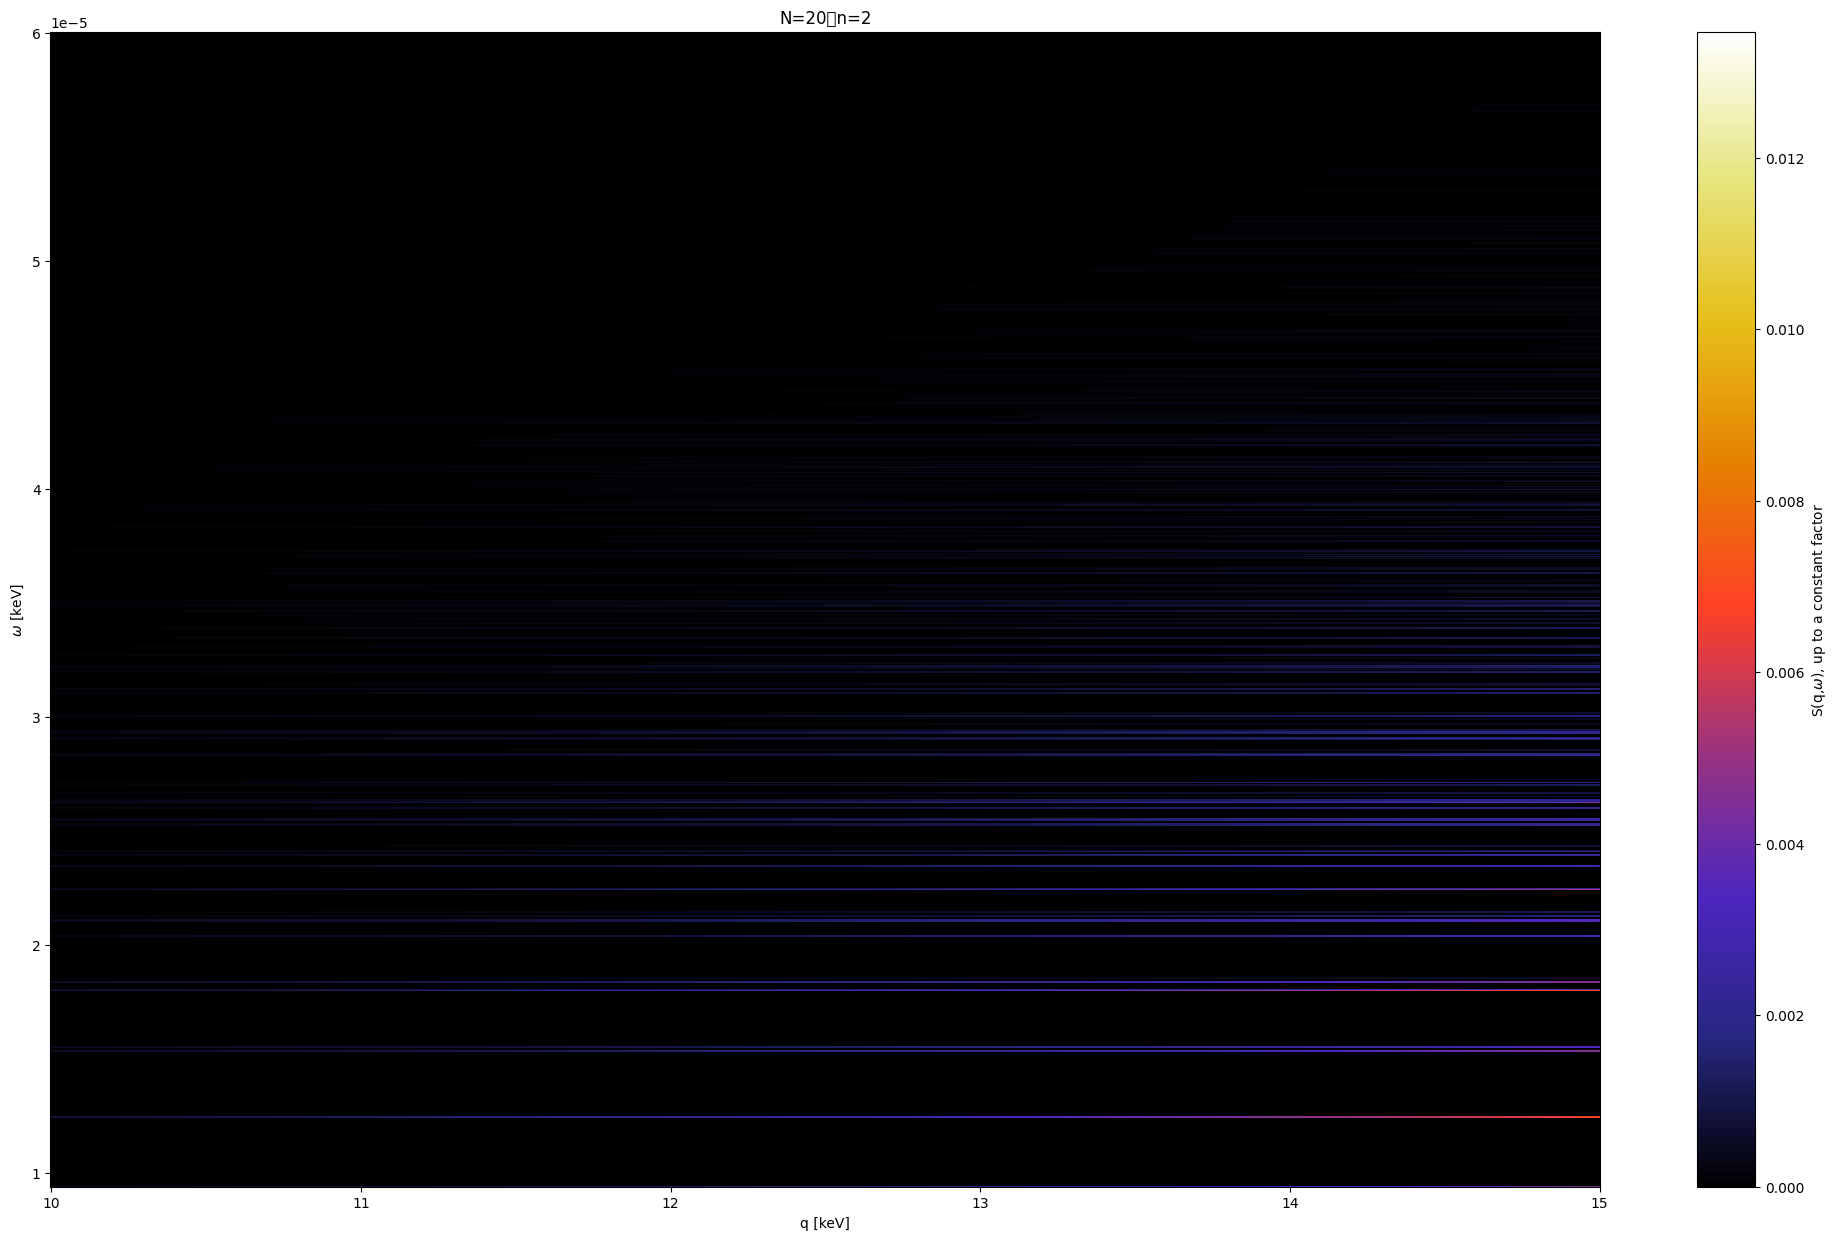

In [28]:
plt.figure(figsize=(25,15))
plt.title('N='+str(N)+"\t"+"n="+str(2))
#plt.plot(q, omega_dispersion_list, color="white", linewidth=1.5, alpha=0.2, linestyle="--", label="Dispersion Relation")
#plt.ylim(0.4e-5, 5e-5)

graph= makeDiagonalsGraph(N, q, SFI_params, combos, 100)
plt.colorbar(graph,label=r'S(q,$\omega$), up to a constant factor')

plt.xlabel("q [keV]")
plt.ylabel(r"$\omega$ [keV]")
#plt.legend(labelcolor="white",framealpha=0.2)

#plt.savefig('Nparticle_structure_factor_2d_one_n', dpi=300,bbox_inches="tight")

plt.show()